#EDA:
Data: Describe how you explored your data, and the process through which you determined your input features.
How did you end up representing your data? What else did you try? We are looking for:

– A thorough exploration of the data, similar to what is presented in labs. What are the distributions of the
features? How do these features correlate with the target?
– If you use figures to answer those questions, an explanation of how you are interpreting those figures. Take
care that your figures can be interpreted meaningfully.
– A clear and logical determination of how you determined your input features, with convincing logical or
empirical evidence justifying your choice. Important features should not be overlooked (e.g., not removed
for “ease”).
– A clear description of the way(s) that you are representing the data in your models.
– The descriptions should be consistent with the .py and/or .ipynb files that you used while developing
your model.
– A clear description of how you are splitting your data into various sets. You may use k-fold cross validation
if you’d like, but if you do, describe how you are applying that idea.


## Exploratory Data Analysis (EDA)



In [1]:
import sys

# Originally authored in Google Colab. Locally there is no google.colab module,
# so skip the upload widget -- cleaned_dataset.csv is already loaded from disk
# in the next cell.
if 'google.colab' in sys.modules:
    from google.colab import files
    uploaded = files.upload()
else:
    print("Not running in Google Colab -- skipping upload widget; "
          "using local cleaned_dataset.csv instead.")

Not running in Google Colab -- skipping upload widget; using local cleaned_dataset.csv instead.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")


display(df.head())

#show summary of data
df.info()
display(df.describe())

,id,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Label
0,42659,4,1.0,2.0,1,Co-worker,"Skyscrapers=>6,Sport=>4,Art and Music=>2,Carni...",25,7.0,100,Slavery,Dubai
1,508149,4,3.0,5.0,2,Co-worker,"Skyscrapers=>6,Sport=>1,Art and Music=>2,Carni...",20,3.0,4,"Wherever there is great property, there is gre...",Dubai
2,496935,5,4.0,5.0,1,"Partner,Friends","Skyscrapers=>6,Sport=>2,Art and Music=>3,Carni...",32,5.0,4,Futuristic land,Dubai
3,502824,5,4.0,4.0,1,"Partner,Friends","Skyscrapers=>6,Sport=>5,Art and Music=>1,Carni...",23,10.0,3,The city where anything is possible,Dubai
4,523028,4,3.0,3.0,3,"Partner,Friends,Siblings","Skyscrapers=>6,Sport=>4,Art and Music=>1,Carni...",20,10.0,5,"If you can think of a high building, it probab...",Dubai


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      1462 non-null   int64  
 1   Q1      1462 non-null   int64  
 2   Q2      1461 non-null   float64
 3   Q3      1461 non-null   float64
 4   Q4      1462 non-null   int64  
 5   Q5      1461 non-null   object 
 6   Q6      1462 non-null   object 
 7   Q7      1461 non-null   object 
 8   Q8      1461 non-null   float64
 9   Q9      1461 non-null   object 
 10  Q10     1419 non-null   object 
 11  Label   1462 non-null   object 
dtypes: float64(3), int64(3), object(6)
memory usage: 137.2+ KB


,id,Q1,Q2,Q3,Q4,Q8
count,1462.000000,1462.000000,1461.000000,1461.000000,1462.000000,1461.000000
mean,460237.614911,4.321477,3.521561,3.707734,3.391929,4.796030
std,112789.365108,0.884464,1.192031,1.142037,1.297189,22.142305
min,5978.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,407927.000000,4.000000,3.000000,3.000000,2.000000,2.000000
50%,503416.000000,5.000000,4.000000,4.000000,3.000000,3.000000
75%,522169.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,727099.000000,5.000000,5.000000,5.000000,5.000000,800.000000


### Data Cleaning: Q7/Q9 are not numeric


In [3]:
df['Q7'] = df['Q7'].astype(str).str.replace(',', '', regex=False).astype(float)
df['Q9'] = df['Q9'].astype(str).str.replace(',', '', regex=False).astype(float)

display(df[['Q7', 'Q9']].describe())

,Q7,Q9
count,1461.000000,1461.000000
mean,21.771732,10.031485
std,262.765201,30.834873
min,-15.000000,0.000000
25%,5.000000,3.000000
50%,15.000000,5.000000
75%,25.000000,10.000000
max,10000.000000,1000.000000


### 1. Distributions of Features

Visualize the distributions of both the numerical and categorical features.

#### Numerical Features

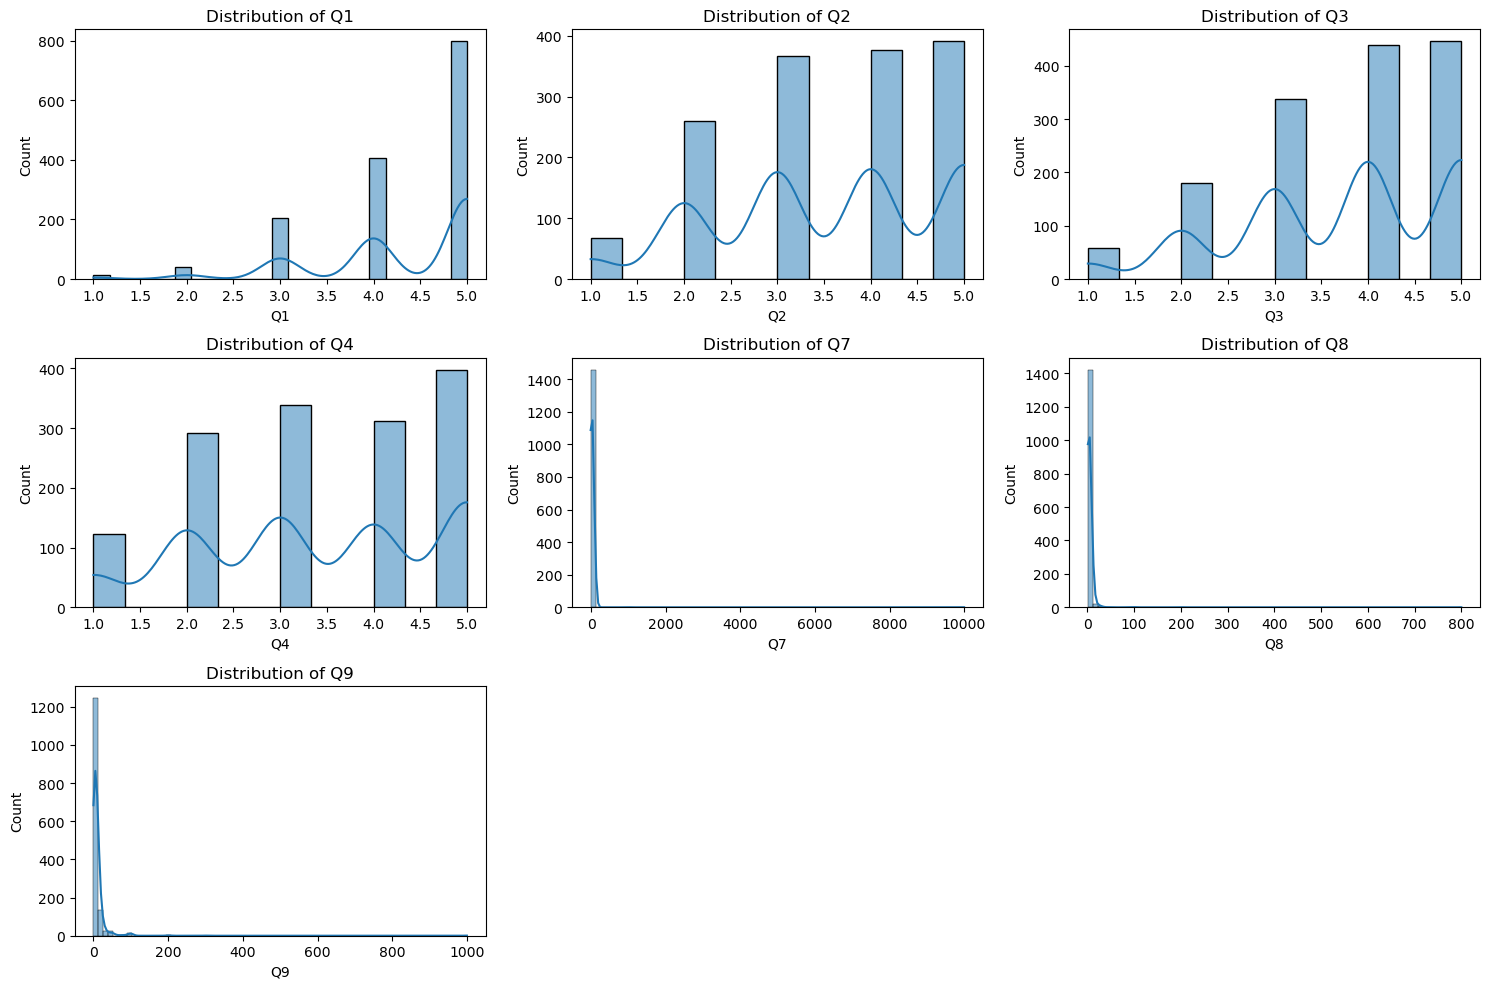

In [4]:
# Identify numerical 'Q' columns (excluding 'id' and 'Label')
numerical_cols = [f'Q{i}' for i in range(1, 11) if f'Q{i}' in df.columns and df[f'Q{i}'].dtype != 'object']

# Plot histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

This tells us:
- all 4 distributions of q1-q4 are right skewed
    - All the citites are generally rated high for popularity, viral, architecture and street party
- Q1 almost had nobody choosing a value below 3
- Q7 - Q9 answers vary highly


#### Categorical Features

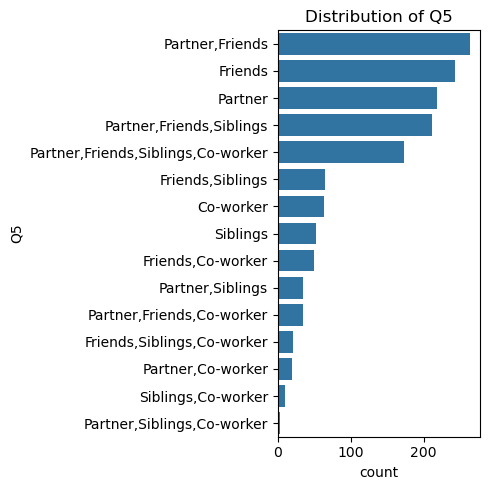

In [5]:

categorical_cols = ['Q5']

# Plot count plots for categorical features
if categorical_cols:
    plt.figure(figsize=(len(categorical_cols) * 5, 5))
    for i, col in enumerate(categorical_cols):
        plt.subplot(1, len(categorical_cols), i + 1)
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No categorical 'Q' features found.")

- From this we can determine:
    - Most people travel in groups that include a Partner and Friends


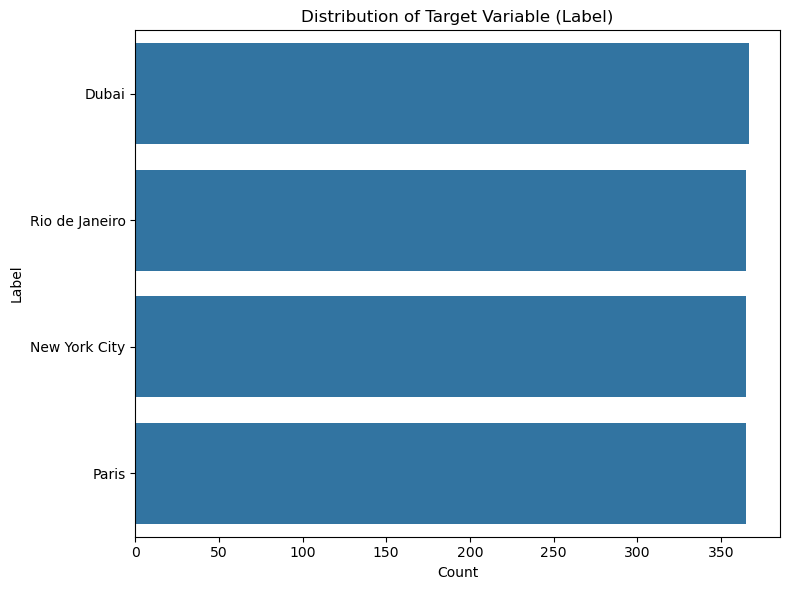

In [6]:
# Distribution of the target variable 'Label'
if 'Label' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(y=df['Label'], order=df['Label'].value_counts().index)
    plt.title('Distribution of Target Variable (Label)')
    plt.xlabel('Count')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()
else:
    print("Target variable 'Label' not found in DataFrame.")

This tells us that there doesn't exist class imbalance, since all labels are equally distributed (same count for each label)

### 2. Correlations between Features

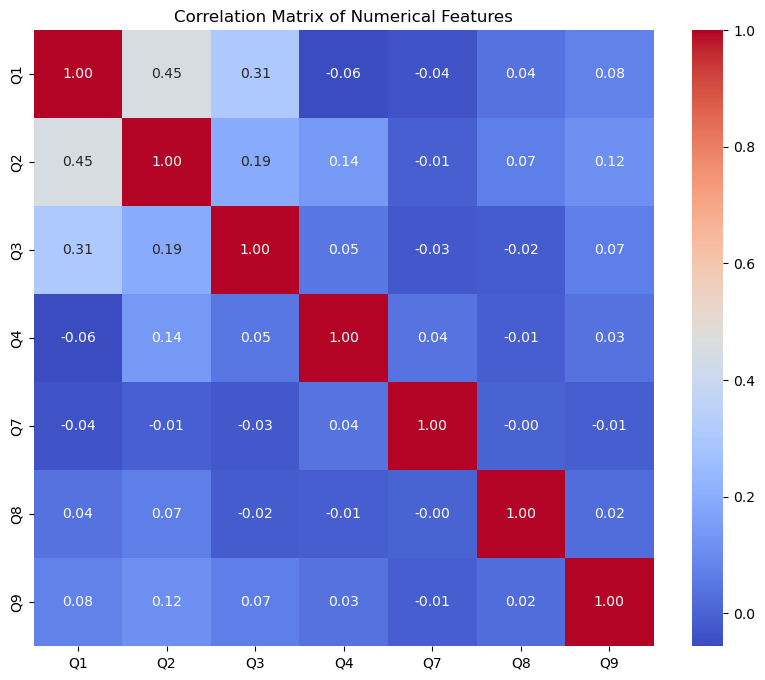

In [7]:

numerical_q_cols = [f'Q{i}' for i in range(1, 11) if f'Q{i}' in df.columns and pd.api.types.is_numeric_dtype(df[f'Q{i}'])]

if numerical_q_cols:
    correlation_matrix = df[numerical_q_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print("No numerical 'Q' features found for correlation analysis.")

Q1, Q2 and Q3 are all somewhat correlated with each other:
    - No redudancy; linear indepedent columns
    - Popularity, virality and architechual uniqueness are correlated with eachother

### 3. Feature-Target Relationships

How each feature correlates with the target variable ('Label').


Exploring Numerical Features vs. Target (Label):


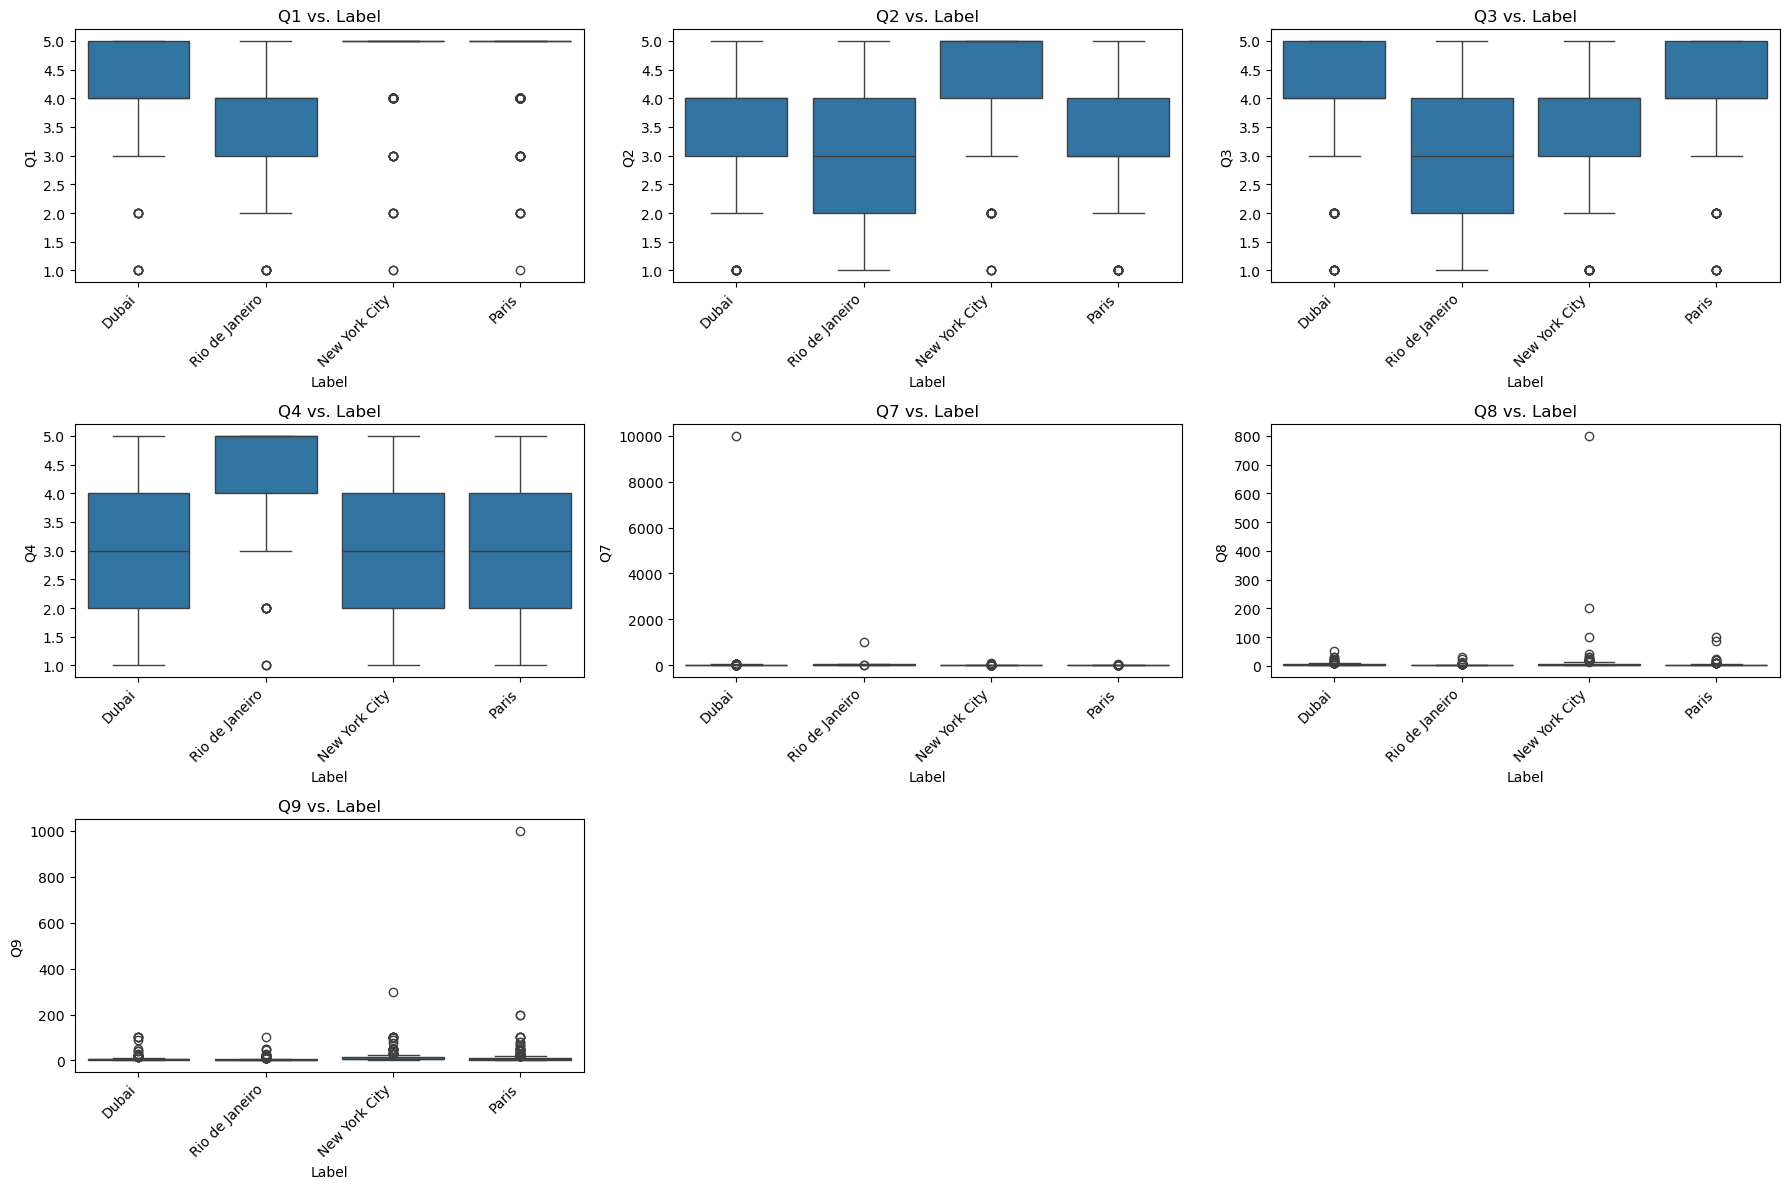


Exploring Categorical Features vs. Target (Label):


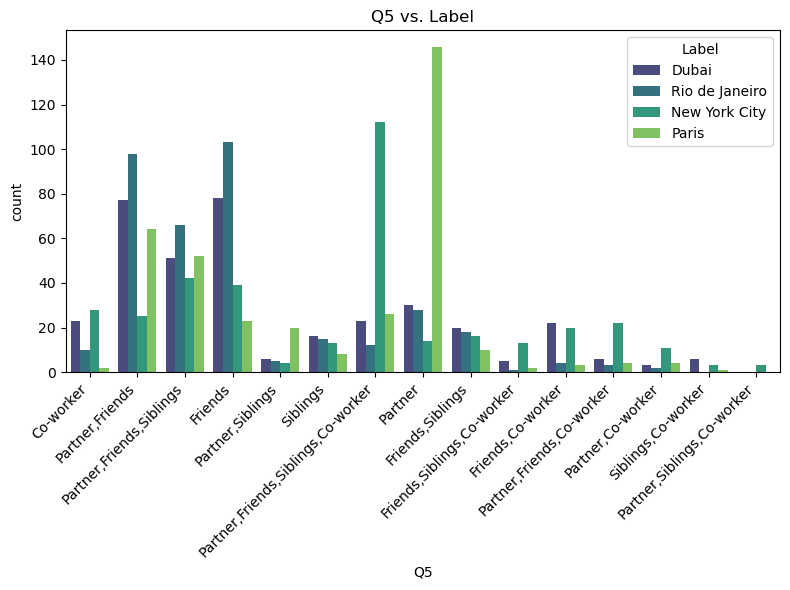

In [8]:
if 'Label' in df.columns:
    # Numerical Features vs. Target ('Label')
    print("\nExploring Numerical Features vs. Target (Label):")
    plt.figure(figsize=(18, 12))
    for i, col in enumerate(numerical_q_cols):
        plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
        sns.boxplot(x='Label', y=col, data=df)
        plt.title(f'{col} vs. Label')
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Categorical Features vs. Target ('Label')
    print("\nExploring Categorical Features vs. Target (Label):")
    if categorical_cols:
        plt.figure(figsize=(len(categorical_cols) * 8, 6))
        for i, col in enumerate(categorical_cols):
            plt.subplot(1, len(categorical_cols), i + 1)
            sns.countplot(x=col, hue='Label', data=df, palette='viridis')
            plt.title(f'{col} vs. Label')
            plt.xticks(rotation=45, ha='right')
            plt.legend(title='Label')
        plt.tight_layout()
        plt.show()
    else:
        print("No categorical 'Q' features to plot against 'Label'.")
else:
    print("Target variable 'Label' not found in DataFrame, skipping feature-target relationship analysis.")

From the boxplots:
- Q4: Rio has a very high median (~4-5) than the other cities. Rio is very stronly associated with Carnival
- Q1: has a the lower median from the other cities. Less popular
- Q2: NYC is significantly more viral than the other citites, Rio is lower
- Q3: Rio is lower than the other citites, while Dubai and Paris are similarly high
- Q7, Q8, Q9 are very noisy

Q5 counts:
- Tells us that friends only is common for Rio/Dubai but rare for Paris
- Partner,Friends,Siblings,Co-worker is very common choice for NYC
- Partner is very associated with Paris
- Rio is common for partner/Friends

### 4. Missing Value Analysis


In [9]:
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
display(missing_summary)

single_missing_cols = ['Q2', 'Q3', 'Q5', 'Q7', 'Q8', 'Q9']
rows_with_missing = df[df[single_missing_cols].isnull().any(axis=1)]
print(f"\n{len(rows_with_missing)} {single_missing_cols}")
display(rows_with_missing[['id'] + single_missing_cols + ['Label']])

,missing_count,missing_pct
Q10,43,2.94
Q2,1,0.07
Q3,1,0.07
Q5,1,0.07
Q7,1,0.07
Q8,1,0.07
Q9,1,0.07



4 ['Q2', 'Q3', 'Q5', 'Q7', 'Q8', 'Q9']


,id,Q2,Q3,Q5,Q7,Q8,Q9,Label
124,519782,1.0,1.0,NaN,24.0,3.0,3.0,Dubai
531,385647,NaN,4.0,"Friends,Co-worker",25.0,2.0,2.0,Rio de Janeiro
652,622833,2.0,NaN,"Partner,Friends,Siblings,Co-worker",20.0,2.0,5.0,Rio de Janeiro
1110,522044,4.0,5.0,"Partner,Friends,Siblings,Co-worker",NaN,NaN,NaN,Paris


**Decision:** Dropping these rows loses under 0.3% of the data so we drop them. We will also fill missing `Q10` with an empty string.

In [10]:
df = df.dropna(subset=single_missing_cols).reset_index(drop=True)
df['Q10'] = df['Q10'].fillna('')
print(f"Shape after dropping rows missing Q2/Q3/Q5/Q7/Q8/Q9: {df.shape}")

Shape after dropping rows missing Q2/Q3/Q5/Q7/Q8/Q9: (1458, 12)


### 5. Decomposing Q6 (Word Ranking) into Numeric Features

`We parse each Q6 value into 6 separate numeric rank columns, one per word.

In [11]:
def parse_q6(s):
    ranks = {}
    for part in str(s).split(","):
        if "=>" not in part:
            continue
        word, rank = part.split("=>")
        ranks[word.strip()] = pd.to_numeric(rank, errors="coerce")
    return pd.Series(ranks)

q6_ranks = df["Q6"].apply(parse_q6)
q6_ranks.columns = ["Q6_" + c.replace(" ", "_") for c in q6_ranks.columns]
q6_cols = list(q6_ranks.columns)


df = df.drop(columns=[c for c in q6_cols if c in df.columns], errors="ignore")
df = pd.concat([df, q6_ranks], axis=1)

print("Missing values:")
print(df[q6_cols].isnull().sum())

df[q6_cols] = df[q6_cols].fillna(df[q6_cols].median())
display(df[q6_cols].describe())

Missing values:
Q6_Skyscrapers      0
Q6_Sport            0
Q6_Art_and_Music    0
Q6_Carnival         0
Q6_Cuisine          1
Q6_Economic         0
dtype: int64


,Q6_Skyscrapers,Q6_Sport,Q6_Art_and_Music,Q6_Carnival,Q6_Cuisine,Q6_Economic
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,3.783951,3.303841,3.987654,3.163923,3.769547,3.890947
std,2.088131,1.720800,1.561764,1.705460,1.403635,1.667580
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000
50%,4.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,6.000000,5.000000,5.000000,4.000000,5.000000,5.000000
max,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


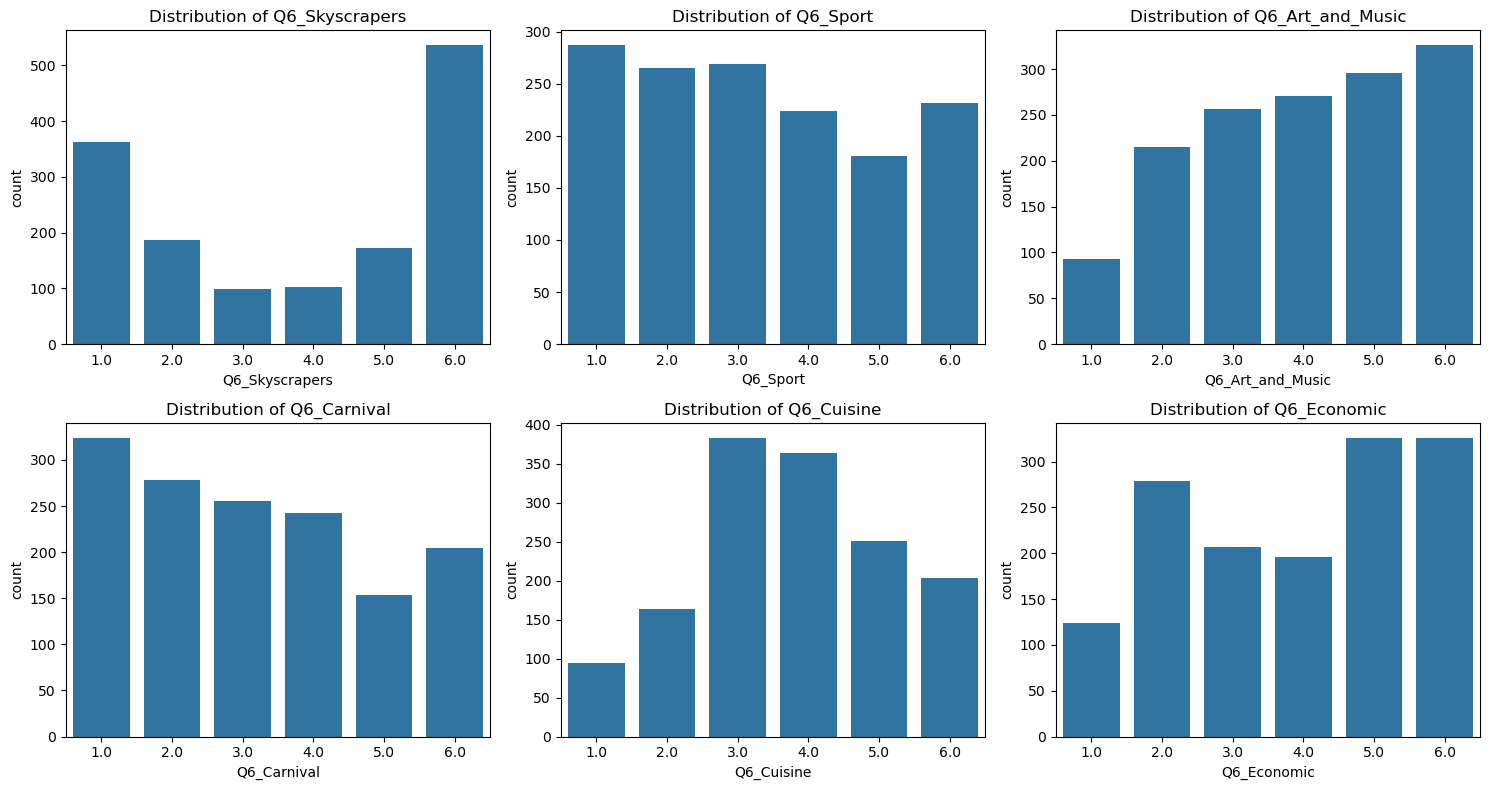

In [12]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(q6_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

,Q6_Skyscrapers,Q6_Sport,Q6_Art_and_Music,Q6_Carnival,Q6_Cuisine,Q6_Economic
Label,,,,,,
Dubai,5.54,2.49,2.59,2.51,3.46,4.89
New York City,5.16,2.76,3.70,2.40,3.42,5.02
Paris,2.66,2.93,5.19,2.89,4.83,3.30
Rio de Janeiro,1.75,5.04,4.47,4.87,3.37,2.34


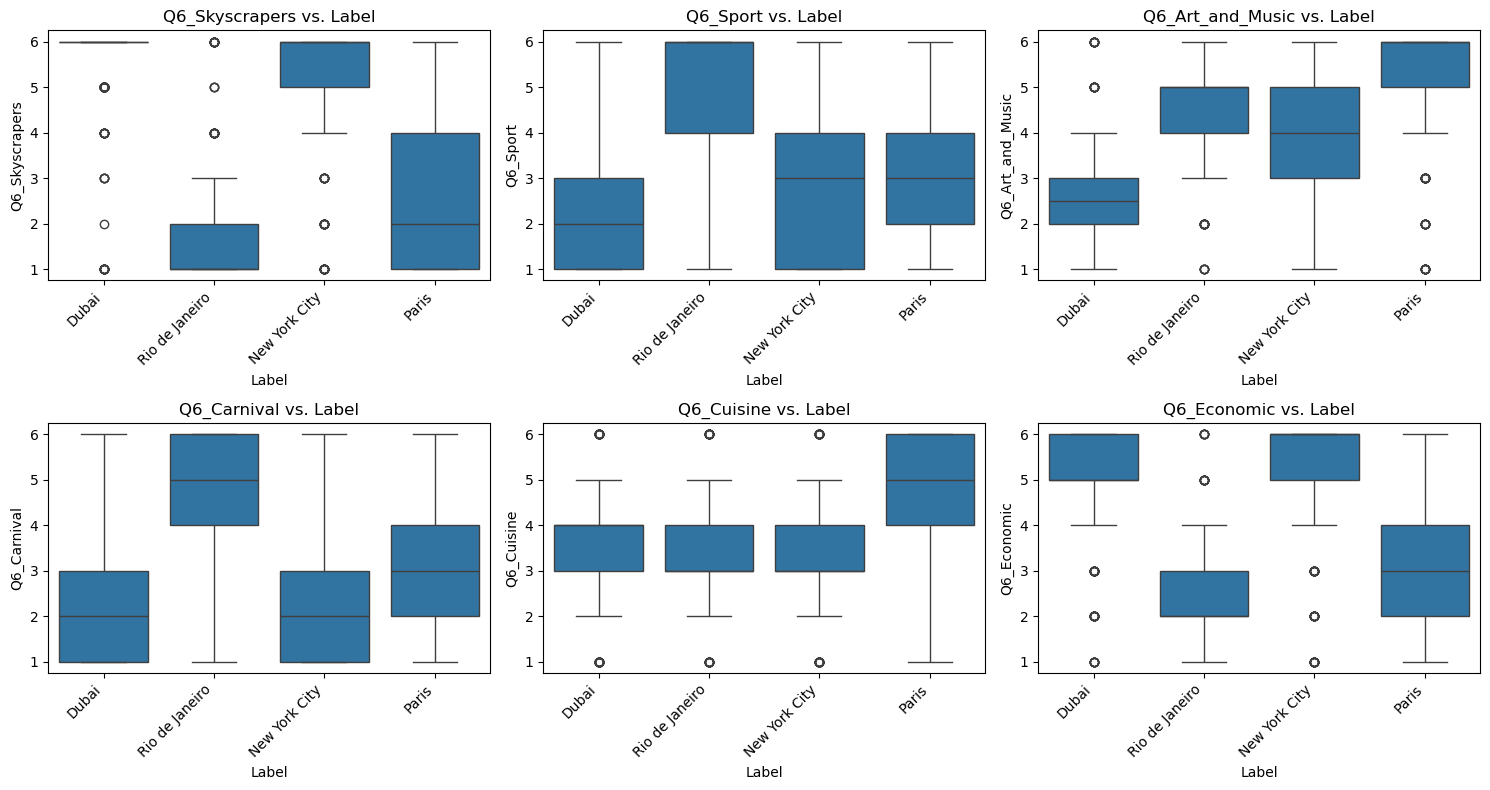

In [13]:
display(df.groupby('Label')[q6_cols].mean().round(2))

plt.figure(figsize=(15, 8))
for i, col in enumerate(q6_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Label', y=col, data=df)
    plt.title(f'{col} vs. Label')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Q6_skyscrapers:
- Dubai and NYC is ranked very high
- Rio and Paris are ranked lower for skyscrapers

Q6_carnival:
- Rio is very high
- Other cities ae low median

Q_6_sport:
- Rio is very high
- Other cities are low

Q_6 Economic:
- Dubai/NYC are very high
- Rio and Paris are lower

Q_6_Art and music
- Dubai low
- Others are similar

Q_6 cuisine:
- Paris high, others are low

Marginal distribution plot:
- Since each column (skyscraper, economic etc.) aren't uniformly distributed we know that there exists a relation between the city and the words associated with it  

### 6. Decomposing Q5 (Travel Companions) into Binary Indicators
 We turn Q5 into a binary indicator column per type..

In [14]:
companion_types = ['Partner', 'Friends', 'Siblings', 'Co-worker']
for c in companion_types:
    df[f'Q5_{c}'] = df['Q5'].fillna('').str.contains(c, regex=False).astype(int)
q5_cols = [f'Q5_{c}' for c in companion_types]
display(df[q5_cols].sum().to_frame('count'))

,count
Q5_Partner,957
Q5_Friends,1057
Q5_Siblings,567
Q5_Co-worker,371


Coworker:
- High for New York
    - When co-worker = 1, NYC is very common
- Low for Rio and Paris

Partner:
- High for Paris
- Even-split yes/no for the other cities

Friends:
- Paris is low

Siblings:
- NYC is slightly high


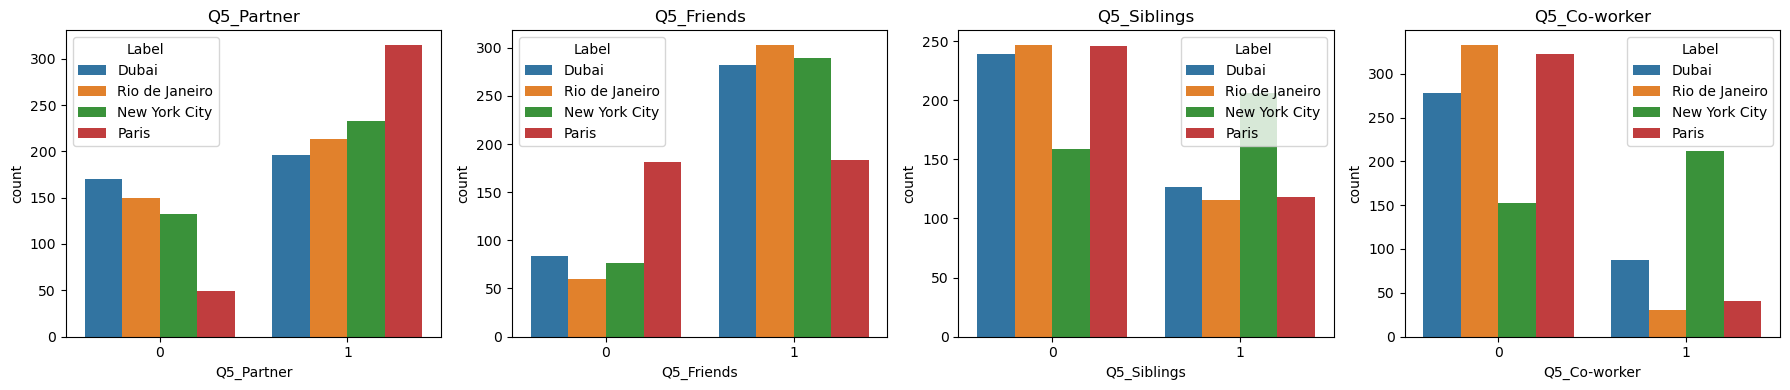

In [15]:
plt.figure(figsize=(18, 4))
for i, col in enumerate(q5_cols):
    plt.subplot(1, 4, i + 1)
    sns.countplot(x=col, hue='Label', data=df)
    plt.title(col)
plt.tight_layout()
plt.show()

### 7. Outliers:


In [16]:
for col in ['Q7', 'Q8', 'Q9']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR fences=({lower:.1f}, {upper:.1f}), outliers={n_outliers}, "
          f"min={df[col].min()}, max={df[col].max()}")

Q7: IQR fences=(-25.0, 55.0), outliers=3, min=-15.0, max=10000.0
Q8: IQR fences=(-2.5, 9.5), outliers=103, min=1.0, max=800.0
Q9: IQR fences=(-7.5, 20.5), outliers=91, min=0.0, max=1000.0


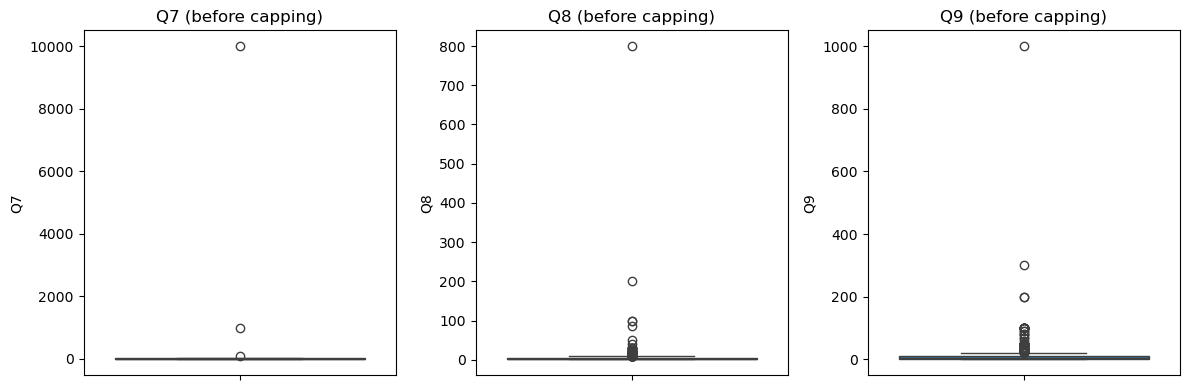

In [17]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(['Q7', 'Q8', 'Q9']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col} (before capping)')
plt.tight_layout()
plt.show()

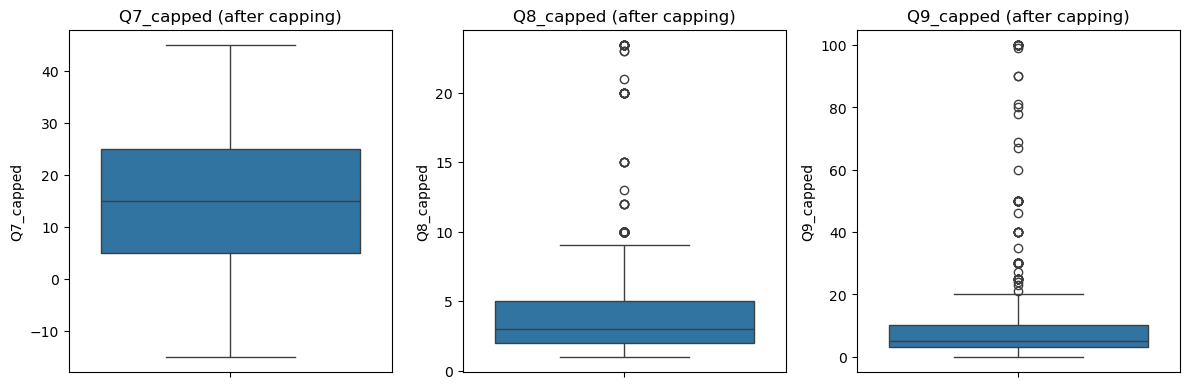

In [18]:

df['Q7_capped'] = df['Q7'].clip(-20, 45)
df['Q8_capped'] = df['Q8'].clip(upper=df['Q8'].quantile(0.99))
df['Q9_capped'] = df['Q9'].clip(upper=df['Q9'].quantile(0.99))

plt.figure(figsize=(12, 4))
for i, col in enumerate(['Q7_capped', 'Q8_capped', 'Q9_capped']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'{col} (after capping)')
plt.tight_layout()
plt.show()

- We replace any value that is beyond a threshold and we change it to a value that is within the range
- This is done to remove the outliers

### 8. Q10 (Free-Text Quote)


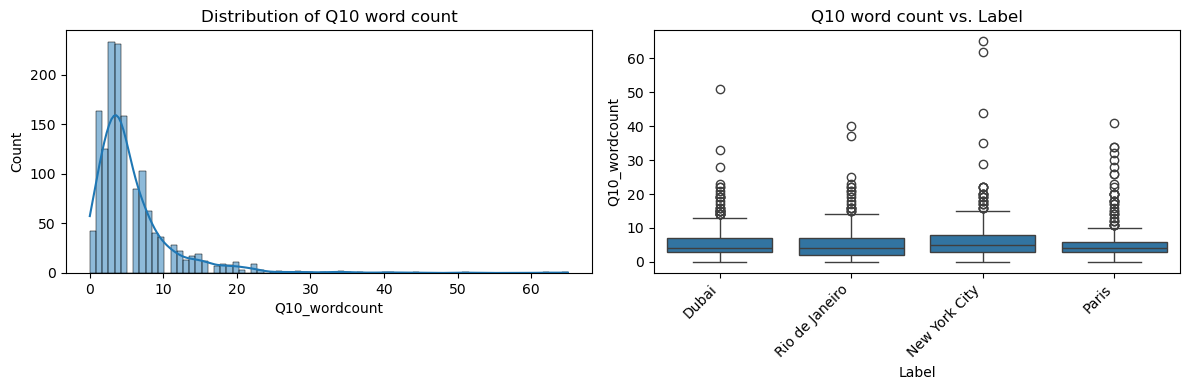

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Dubai,366.0,5.885246,5.293361,0.0,3.0,4.0,7.0,51.0
New York City,365.0,6.769863,6.792584,0.0,3.0,5.0,8.0,65.0
Paris,364.0,5.296703,5.581343,0.0,3.0,4.0,6.0,41.0
Rio de Janeiro,363.0,5.121212,4.978036,0.0,2.0,4.0,7.0,40.0


In [19]:
df['Q10_wordcount'] = df['Q10'].fillna('').str.split().str.len()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Q10_wordcount'], kde=True)
plt.title('Distribution of Q10 word count')
plt.subplot(1, 2, 2)
sns.boxplot(x='Label', y='Q10_wordcount', data=df)
plt.title('Q10 word count vs. Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby('Label')['Q10_wordcount'].describe())

In [20]:
import re
from collections import Counter

stopwords = {
    'the', 'a', 'an', 'is', 'it', 'of', 'in', 'and', 'to', 'this', 'that',
    'you', 'i', 'for', 'with', 'on', 'are', 'its', 'was', 'as', 'be', 'at',
}

def top_words(text_series, n=10):
    words = []
    for text in text_series:
        words.extend(w for w in re.findall(r"[a-z']+", str(text).lower()) if w not in stopwords)
    return Counter(words).most_common(n)

for city in df['Label'].unique():
    print(f"\nTop words for {city}:")
    print(top_words(df.loc[df['Label'] == city, 'Q10']))


Top words for Dubai:
[('dubai', 62), ('rich', 50), ('city', 45), ('money', 44), ('habibi', 24), ('come', 23), ('where', 18), ('world', 17), ('not', 17), ('tallest', 15)]

Top words for Rio de Janeiro:
[('rio', 42), ('city', 40), ('football', 33), ('life', 30), ('brazil', 22), ('de', 21), ('carnival', 20), ('janeiro', 20), ("it's", 19), ('soccer', 19)]

Top words for New York City:
[('new', 104), ('york', 90), ('city', 75), ('dreams', 74), ('where', 64), ('made', 62), ('concrete', 53), ('jungle', 45), ('never', 41), ('sleeps', 39)]

Top words for Paris:
[('city', 136), ('love', 109), ('paris', 61), ('la', 21), ('tower', 21), ('oui', 20), ('eiffel', 19), ('baguette', 16), ('romance', 16), ('romantic', 15)]


In [21]:
keyword_map = {
    'Q10_kw_tallest': 'tallest',
    'Q10_kw_carnival': 'carnival',
    'Q10_kw_eiffel': 'eiffel',
    'Q10_kw_skyscraper': 'skyscraper',
}
for col, kw in keyword_map.items():
    df[col] = df['Q10'].fillna('').str.lower().str.contains(kw, regex=False).astype(int)
display(df[list(keyword_map.keys())].sum())

Q10_kw_tallest       15
Q10_kw_carnival      27
Q10_kw_eiffel        19
Q10_kw_skyscraper    15
dtype: int64

`Q10_wordcount` and the keyword indicators are just secondary/optional features since the results are very noisy.

### 9. Grouping answers to their ID's


In [22]:
id_counts = df['id'].value_counts()
print(id_counts.value_counts())
print(f"\n{df['id'].nunique()} unique ids across {len(df)} rows")

count
4    361
3      4
1      2
Name: count, dtype: int64

367 unique ids across 1458 rows


Most respondents contribute one row per city (so most `id`s appear multiple times); The model could learn that respondent's personal rating patterns rather than genuine city patterns. We avoid this with a **group-based split**: all rows sharing an `id` are kept together in the same split.

In [23]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(df, groups=df['id']))
train_df, temp_df = df.iloc[train_idx], df.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['id']))
val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

assert set(train_df['id']) & set(val_df['id']) == set()
assert set(train_df['id']) & set(test_df['id']) == set()
assert set(val_df['id']) & set(test_df['id']) == set()

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"\n{name} class balance:")
    print(split_df['Label'].value_counts(normalize=True).round(3))

train=1017, val=218, test=223

train class balance:
Label
Dubai             0.252
Rio de Janeiro    0.250
New York City     0.250
Paris             0.249
Name: proportion, dtype: float64

val class balance:
Label
Dubai             0.252
New York City     0.252
Paris             0.252
Rio de Janeiro    0.243
Name: proportion, dtype: float64

test class balance:
Label
Rio de Janeiro    0.251
New York City     0.251
Paris             0.251
Dubai             0.247
Name: proportion, dtype: float64


This makes a ~70/15/15 split with no respondent appearing in more than one split, and the per-split class balance should stay close to the overall ~25% per city.

### 10. Feature Summary

1. Feature Distribution:
- all 4 distributions of q1-q4 are right skewed
    - All the citites are generally rated high for popularity, viral, architecture and street party
- Q5:
    - Most people travel in groups that include a Partner and Friends
    - Friends only
    - Partner

- Q1 almost had nobody choosing a value below 3
- Q7 - Q9 answers vary highly
- Target Distribution:
    - All evenly distributed among 4 classes
    - No class imbalance


2. Correlation Between Features
    - Q1, Q2 and Q3 are all somewhat correlated with each other:
        - No redudancy; linear indepedent columns
        - Popularity, virality and architechual uniqueness are correlated with eachother
3. Correlation between features and target
    From the boxplots:
    - Q4: Rio has a very high median (~4-5) than the other cities. Rio is very strongly associated with Carnival
    - Q1: has a the lower median from the other cities. Less popular
    - Q2: NYC is significantly more viral than the other citites, Rio is lower
    - Q3: Rio is lower than the other citites, while Dubai and Paris are similarly high
    - Q7, Q8, Q9 are very noisy

    Q5:
    - Tells us that friends only is common for Rio/Dubai but rare for Paris
    - Partner,Friends,Siblings,Co-worker is very common choice for NYC
    - Partner is very associated with Paris
    - Rio is common for partner/Friends

    Coworker:
    - High for New York
        - When co-worker = 1, NYC is very common
    - Low for Rio and Paris

    Partner:
    - High for Paris
    - Even-split yes/no for the other cities

    Friends:
    - Paris is low

    Siblings:
    - NYC is slightly high


    Q6:
        Q6_skyscrapers:
        - Dubai and NYC is ranked very high
        - Rio and Paris are ranked lower for skyscrapers

        Q6_carnival:
        - Rio is very high
        - Other cities ae low median

        Q_6_sport:
        - Rio is very high
        - Other cities are low

        Q_6 Economic:
        - Dubai/NYC are very high
        - Rio and Paris are lower

        Q_6_Art and music
        - Dubai low
        - Others are similar

        Q_6 cuisine:
        - Paris high, others are low




- **Q7_capped / Q8_capped / Q9_capped** (Section 7): kept in their capped form rather than the raw columns, since the raw columns contain outliers that would dominate any distance- or scale-sensitive model.
- **Q10_wordcount and Q10 keyword indicators** (Section 8): is kept as optional/secondary features only, given Q10 has the most missing values of any column (43 rows, ~2.9%), its signal is unstructured and noisier than the other questions.
- **`id`**: its only role as a feature is defining the group-based train/val/test split in Section 9.

**Data representation:** each row becomes a numeric feature vector with Q1-Q4 the same,  four Q5 binary indicators, six Q6 rank columns, the three capped Q7/Q8/Q9 columns, and Q10 count/keyword features -- with `Label` as the target class to predict.

**Split strategy:** group-based 70/15/15 train/val/test split by `id` (Section 9), so no respondent's answers appear in more than one split.

### 11. Fix: leak-free split + capping + final feature matrix

The Q7-9 capping earlier (cell 38) was computed on the full `df` before splitting, which lets val/test rows influence the train-time clip bounds. Fixing by doing split first, then compute clip bounds from `train_df` only, then create the final feature matrices.

In [24]:
# Re-split first
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(df, groups=df['id']))
train_df, temp_df = df.iloc[train_idx].copy(), df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['id']))
val_df, test_df = temp_df.iloc[val_idx].copy(), temp_df.iloc[test_idx].copy()

assert set(train_df['id']) & set(val_df['id']) == set()
assert set(train_df['id']) & set(test_df['id']) == set()
assert set(val_df['id']) & set(test_df['id']) == set()

print(f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

train=1017, val=218, test=223


In [25]:
# Compute Q7-9 clip bounds from train only, apply the same fixed bounds to all splits
q7_lo, q7_hi = -20, 45
q8_hi = train_df['Q8'].quantile(0.99)
q9_hi = train_df['Q9'].quantile(0.99)

for split in (train_df, val_df, test_df):
    split['Q7_capped'] = split['Q7'].clip(q7_lo, q7_hi)
    split['Q8_capped'] = split['Q8'].clip(upper=q8_hi)
    split['Q9_capped'] = split['Q9'].clip(upper=q9_hi)

print(f"q7 bounds: [{q7_lo}, {q7_hi}], q8_hi={q8_hi:.2f}, q9_hi={q9_hi:.2f}")

q7 bounds: [-20, 45], q8_hi=14.68, q9_hi=100.00


In [26]:
# Create final feature matrices for modeling
feature_cols = (
    ['Q1', 'Q2', 'Q3', 'Q4']
    + q5_cols
    + q6_cols
    + ['Q7_capped', 'Q8_capped', 'Q9_capped', 'Q10_wordcount']
    + list(keyword_map.keys())
)

X_train, y_train = train_df[feature_cols], train_df['Label']
X_val, y_val = val_df[feature_cols], val_df['Label']
X_test, y_test = test_df[feature_cols], test_df['Label']

print(X_train.shape, X_val.shape, X_test.shape)

(1017, 22) (218, 22) (223, 22)


### 12. Export train/val/test feature sets to CSV

Model-exploration notebooks can just load these directly

In [27]:
# Include raw Q7/Q8/Q9 alongside the capped versions so that anything
# training on these CSVs (e.g. train.py) can recompute its own capping
# bounds if it uses a different population (e.g. train+val combined)
# instead of being stuck with bounds baked in at export time.
train_df[['id'] + feature_cols + ['Q7', 'Q8', 'Q9'] + ['Label']].to_csv('train_features.csv', index=False)
val_df[['id'] + feature_cols + ['Q7', 'Q8', 'Q9'] + ['Label']].to_csv('val_features.csv', index=False)
test_df[['id'] + feature_cols + ['Q7', 'Q8', 'Q9'] + ['Label']].to_csv('test_features.csv', index=False)

print('Saved train_features.csv, val_features.csv, test_features.csv')

Saved train_features.csv, val_features.csv, test_features.csv


## Model Training

### Model 1: Decision Tree (sklearn)

Exploring a decision tree first since it needs no feature scaling and handles the mix of ordinal (Q1-Q4), binary (Q5, Q10 keywords), rank (Q6), and noisy continuous (Q7-Q9) features directly. This uses `sklearn` for fast comparison against other model families; the final `pred.py` submission will reimplement whichever model wins in plain numpy.

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Baseline: unconstrained tree (no max_depth) to see how badly it overfits
tree_baseline = DecisionTreeClassifier(random_state=42)
tree_baseline.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_baseline.predict(X_train))
val_acc = accuracy_score(y_val, tree_baseline.predict(X_val))
print(f"Unconstrained tree -- train acc: {train_acc:.3f}, val acc: {val_acc:.3f}, depth: {tree_baseline.get_depth()}")

Unconstrained tree -- train acc: 1.000, val acc: 0.803, depth: 16


**Hyperparameter tuning: `max_depth`**

Sweeping `max_depth` to find where the tree stops underfitting but hasn't started overfitting (train/val accuracy gap widening).

,max_depth,train_acc,val_acc
0,1,0.455261,0.458716
1,2,0.796460,0.816514
2,3,0.806293,0.788991
3,4,0.852507,0.857798
4,5,0.879056,0.830275
5,6,0.903638,0.821101
6,7,0.936087,0.834862
7,8,0.963618,0.811927
8,9,0.980334,0.839450
9,10,0.988201,0.811927


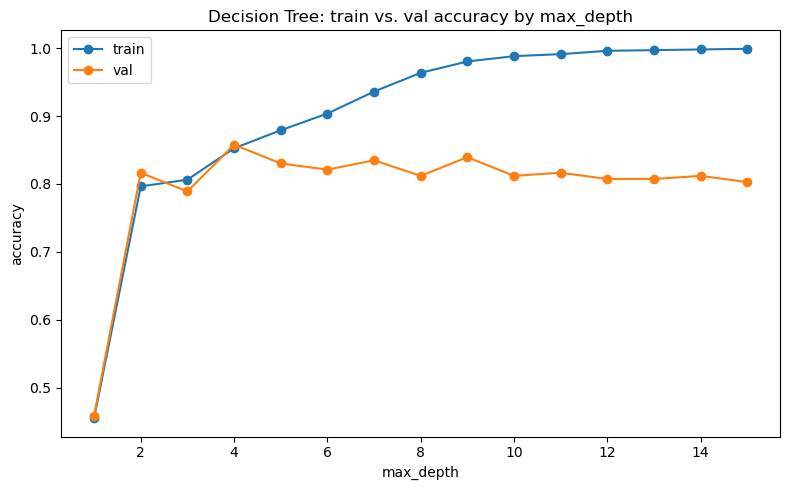

Best max_depth by val accuracy: 4


In [29]:
depths = list(range(1, 16))
results = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    results.append({
        'max_depth': d,
        'train_acc': accuracy_score(y_train, clf.predict(X_train)),
        'val_acc': accuracy_score(y_val, clf.predict(X_val)),
    })

results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df['max_depth'], results_df['train_acc'], marker='o', label='train')
plt.plot(results_df['max_depth'], results_df['val_acc'], marker='o', label='val')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Decision Tree: train vs. val accuracy by max_depth')
plt.legend()
plt.tight_layout()
plt.show()

best_depth = results_df.loc[results_df['val_acc'].idxmax(), 'max_depth']
print(f"Best max_depth by val accuracy: {best_depth}")

Final tree (max_depth=4) -- train acc: 0.853, val acc: 0.858

Classification report (val):
                precision    recall  f1-score   support

         Dubai       0.88      0.82      0.85        55
 New York City       0.86      0.87      0.86        55
         Paris       0.77      0.87      0.82        55
Rio de Janeiro       0.94      0.87      0.90        53

      accuracy                           0.86       218
     macro avg       0.86      0.86      0.86       218
  weighted avg       0.86      0.86      0.86       218



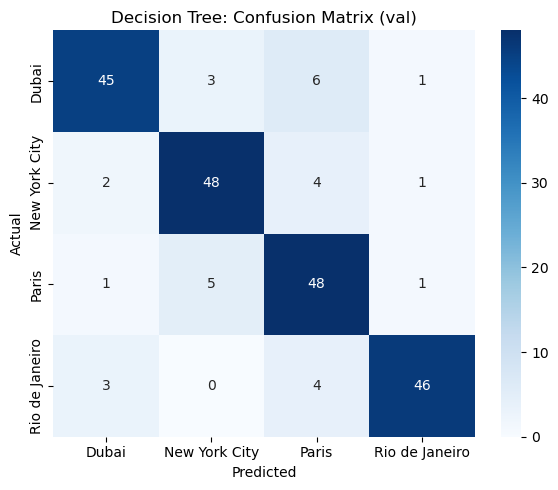

,importance
Q7_capped,0.321088
Q6_Skyscrapers,0.296362
Q6_Economic,0.176729
Q4,0.034083
Q2,0.033906
Q5_Co-worker,0.031725
Q6_Cuisine,0.027672
Q6_Carnival,0.024290
Q3,0.016299
Q6_Sport,0.013726


In [30]:
tree_final = DecisionTreeClassifier(max_depth=int(best_depth), random_state=42)
tree_final.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_final.predict(X_train))
val_acc = accuracy_score(y_val, tree_final.predict(X_val))
print(f"Final tree (max_depth={best_depth}) -- train acc: {train_acc:.3f}, val acc: {val_acc:.3f}")

val_pred = tree_final.predict(X_val)
print("\nClassification report (val):")
print(classification_report(y_val, val_pred))

labels = sorted(y_train.unique())
cm = confusion_matrix(y_val, val_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree: Confusion Matrix (val)')
plt.tight_layout()
plt.show()

importances = pd.Series(tree_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances.to_frame('importance'))

### Model 1b: Hyperparameter Selection via Group K-Fold Cross-Validation

The single train/val split above has only 218 val rows, so its "best `max_depth`" pick is somewhat noisy. Using **`GroupKFold`** (grouped by respondent `id`, same reasoning as the original train/val/test split) on `train_df` gives a more reliable estimate: each hyperparameter combination is scored across 5 folds, and we look at both the mean and the spread of those fold accuracies.

In [31]:
from sklearn.model_selection import GroupKFold
import numpy as np

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_leaf': [1, 5, 10, 20],
}

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
groups = train_df['id'].values

cv_results = []
for max_depth in param_grid['max_depth']:
    for min_samples_leaf in param_grid['min_samples_leaf']:
        fold_accs = []
        for fold_train_idx, fold_val_idx in gkf.split(X_train, y_train, groups=groups):
            clf = DecisionTreeClassifier(
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
            )
            clf.fit(X_train.iloc[fold_train_idx], y_train.iloc[fold_train_idx])
            fold_acc = accuracy_score(
                y_train.iloc[fold_val_idx], clf.predict(X_train.iloc[fold_val_idx])
            )
            fold_accs.append(fold_acc)
        cv_results.append({
            'max_depth': max_depth,
            'min_samples_leaf': min_samples_leaf,
            'fold_accs': fold_accs,
            'mean_acc': np.mean(fold_accs),
            'std_acc': np.std(fold_accs),
        })

cv_df = pd.DataFrame(cv_results).sort_values('mean_acc', ascending=False).reset_index(drop=True)
display(cv_df[['max_depth', 'min_samples_leaf', 'mean_acc', 'std_acc']].head(10))

,max_depth,min_samples_leaf,mean_acc,std_acc
0,5.0,5,0.818022,0.045806
1,4.0,1,0.813129,0.037096
2,5.0,10,0.812130,0.053225
3,7.0,5,0.811188,0.041648
4,8.0,5,0.810208,0.038385
5,NaN,5,0.809198,0.039252
6,6.0,5,0.809198,0.045078
7,4.0,10,0.809179,0.037798
8,4.0,5,0.808213,0.036317
9,6.0,10,0.807203,0.048366


In [32]:
# Sanity check: confirm GroupKFold never splits a respondent's rows
# across the fold-train/fold-val boundary within this CV loop.
gkf_check = GroupKFold(n_splits=N_SPLITS)
for i, (tr_idx, va_idx) in enumerate(gkf_check.split(X_train, y_train, groups=groups)):
    tr_ids = set(groups[tr_idx])
    va_ids = set(groups[va_idx])
    overlap = tr_ids & va_ids
    print(f"Fold {i}: train ids={len(tr_ids)}, val ids={len(va_ids)}, overlapping ids={len(overlap)}")
    assert not overlap, f"Leak in fold {i}: ids {overlap} appear on both sides"
print("\nNo respondent id appears on both sides of any fold.")

Fold 0: train ids=205, val ids=51, overlapping ids=0
Fold 1: train ids=205, val ids=51, overlapping ids=0
Fold 2: train ids=205, val ids=51, overlapping ids=0
Fold 3: train ids=205, val ids=51, overlapping ids=0
Fold 4: train ids=204, val ids=52, overlapping ids=0

No respondent id appears on both sides of any fold.


Best params: max_depth=5, min_samples_leaf=5
Per-fold accuracy scores: [0.877, 0.755, 0.853, 0.828, 0.777]
Mean: 0.818  Std: 0.046


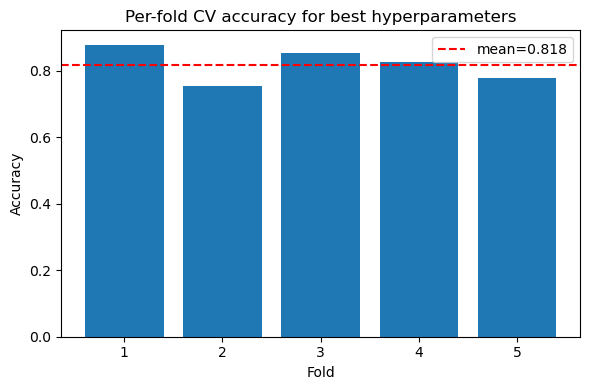


Refit on full train -- train acc: 0.872, val acc: 0.821


In [33]:
best_row = cv_df.iloc[0]
best_max_depth = None if pd.isna(best_row['max_depth']) else int(best_row['max_depth'])
best_min_samples_leaf = int(best_row['min_samples_leaf'])

print(f"Best params: max_depth={best_max_depth}, min_samples_leaf={best_min_samples_leaf}")
print(f"Per-fold accuracy scores: {[round(a, 3) for a in best_row['fold_accs']]}")
print(f"Mean: {best_row['mean_acc']:.3f}  Std: {best_row['std_acc']:.3f}")

plt.figure(figsize=(6, 4))
plt.bar(range(1, N_SPLITS + 1), best_row['fold_accs'])
plt.axhline(best_row['mean_acc'], color='red', linestyle='--', label=f"mean={best_row['mean_acc']:.3f}")
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Per-fold CV accuracy for best hyperparameters')
plt.xticks(range(1, N_SPLITS + 1))
plt.legend()
plt.tight_layout()
plt.show()

# Refit on the full training set with the CV-selected hyperparameters,
# then check once against the held-out validation set.
tree_cv = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_leaf=best_min_samples_leaf,
    random_state=42,
)
tree_cv.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_cv.predict(X_train))
val_acc = accuracy_score(y_val, tree_cv.predict(X_val))
print(f"\nRefit on full train -- train acc: {train_acc:.3f}, val acc: {val_acc:.3f}")

### Model 1c: Ensemble Methods (Random Forest & Gradient Boosting)

Bagging (Random Forest) and boosting (Gradient Boosting) both build on the single decision tree above, and should reduce the fold-to-fold variance (std ~0.046) seen in the single-tree CV. Reusing the same `GroupKFold`-by-`id` setup so results are directly comparable to the single tree's mean CV accuracy of 0.818.

In [34]:
from itertools import product

def group_kfold_grid_search(model_cls, param_grid, X, y, groups, n_splits=5, random_state=42, fixed_params=None):
    fixed_params = fixed_params or {}
    gkf = GroupKFold(n_splits=n_splits)
    keys = list(param_grid.keys())
    rows = []
    for combo in product(*param_grid.values()):
        params = dict(zip(keys, combo))
        fold_accs = []
        for tr_idx, va_idx in gkf.split(X, y, groups=groups):
            clf = model_cls(random_state=random_state, **params, **fixed_params)
            clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            fold_accs.append(accuracy_score(y.iloc[va_idx], clf.predict(X.iloc[va_idx])))
        rows.append({**params, 'fold_accs': fold_accs, 'mean_acc': np.mean(fold_accs), 'std_acc': np.std(fold_accs)})
    return pd.DataFrame(rows).sort_values('mean_acc', ascending=False).reset_index(drop=True)

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10],
}
rf_cv_df = group_kfold_grid_search(
    RandomForestClassifier, rf_param_grid, X_train, y_train, groups,
    fixed_params={'n_jobs': -1},
)
display(rf_cv_df.drop(columns='fold_accs').head(10))

,n_estimators,max_depth,min_samples_leaf,mean_acc,std_acc
0,300,10.0,1,0.890861,0.021977
1,100,NaN,1,0.890857,0.016518
2,100,10.0,1,0.889876,0.021146
3,300,NaN,1,0.888906,0.016178
4,300,7.0,1,0.886930,0.018293
5,100,7.0,1,0.883960,0.022335
6,100,7.0,5,0.881989,0.025832
7,300,7.0,5,0.881029,0.025232
8,100,5.0,1,0.881024,0.020647
9,300,5.0,5,0.880029,0.026467


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
}
gb_cv_df = group_kfold_grid_search(
    GradientBoostingClassifier, gb_param_grid, X_train, y_train, groups,
)
display(gb_cv_df.drop(columns='fold_accs').head(10))

,n_estimators,max_depth,learning_rate,mean_acc,std_acc
0,200,4,0.10,0.895744,0.021494
1,200,2,0.05,0.891813,0.025313
2,200,3,0.10,0.891798,0.031312
3,200,3,0.20,0.891798,0.025566
4,200,4,0.05,0.890847,0.025487
5,100,4,0.10,0.890832,0.024792
6,100,3,0.10,0.889857,0.025367
7,100,4,0.20,0.889837,0.026390
8,100,4,0.05,0.888872,0.024995
9,100,2,0.20,0.888857,0.032284


,model,mean_acc,std_acc
0,Gradient Boosting,0.895744,0.021494
1,Random Forest,0.890861,0.021977
2,Decision Tree,0.818022,0.045806


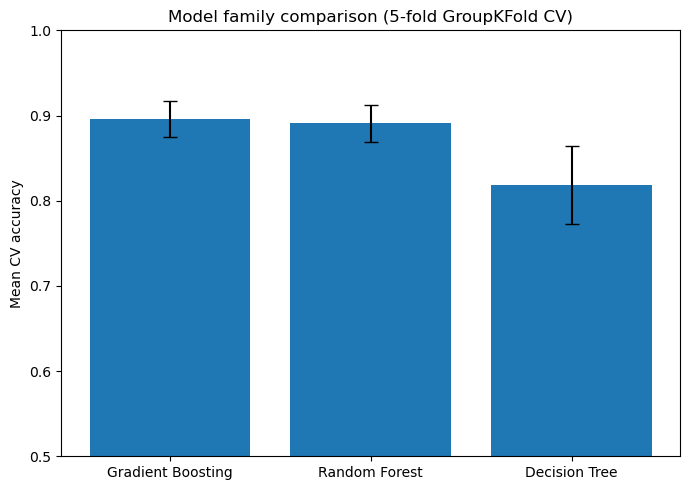

In [37]:
# Compare best CV result from each model family explored so far
comparison = pd.DataFrame([
    {'model': 'Decision Tree', **{k: best_row[k] for k in ('mean_acc', 'std_acc')}},
    {'model': 'Random Forest', **{k: rf_cv_df.iloc[0][k] for k in ('mean_acc', 'std_acc')}},
    {'model': 'Gradient Boosting', **{k: gb_cv_df.iloc[0][k] for k in ('mean_acc', 'std_acc')}},
]).sort_values('mean_acc', ascending=False).reset_index(drop=True)
display(comparison)

plt.figure(figsize=(7, 5))
plt.bar(comparison['model'], comparison['mean_acc'], yerr=comparison['std_acc'], capsize=5)
plt.ylabel('Mean CV accuracy')
plt.title('Model family comparison (5-fold GroupKFold CV)')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [38]:
# Refit whichever model family had the best mean CV accuracy on the full training set,
# then check once against the held-out validation set.
best_family = comparison.iloc[0]['model']

if best_family == 'Random Forest':
    p = rf_cv_df.iloc[0]
    best_model = RandomForestClassifier(
        n_estimators=int(p['n_estimators']),
        max_depth=None if pd.isna(p['max_depth']) else int(p['max_depth']),
        min_samples_leaf=int(p['min_samples_leaf']),
        random_state=42, n_jobs=-1,
    )
elif best_family == 'Gradient Boosting':
    p = gb_cv_df.iloc[0]
    best_model = GradientBoostingClassifier(
        n_estimators=int(p['n_estimators']),
        max_depth=int(p['max_depth']),
        learning_rate=float(p['learning_rate']),
        random_state=42,
    )
else:
    best_model = tree_cv

print(f"Best model family: {best_family}")
best_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, best_model.predict(X_train))
val_acc = accuracy_score(y_val, best_model.predict(X_val))
print(f"Train acc: {train_acc:.3f}, Val acc: {val_acc:.3f}")

val_pred = best_model.predict(X_val)
print("\nClassification report (val):")
print(classification_report(y_val, val_pred))

Best model family: Gradient Boosting


Train acc: 1.000, Val acc: 0.931

Classification report (val):
                precision    recall  f1-score   support

         Dubai       0.91      0.89      0.90        55
 New York City       0.93      0.96      0.95        55
         Paris       0.94      0.91      0.93        55
Rio de Janeiro       0.94      0.96      0.95        53

      accuracy                           0.93       218
     macro avg       0.93      0.93      0.93       218
  weighted avg       0.93      0.93      0.93       218



## Model 2: Neural Network (MLP with Softmax Output)

sklearn's `MLPClassifier` already uses a softmax output layer + cross-entropy loss automatically for multi-class problems, so no extra configuration is needed for that part. Unlike the tree-based models, an MLP is scale-sensitive (like kNN), so features need standardizing -- but since scaling stats must come from *training* data only, the scaler has to be fit **inside each CV fold** (fit on the fold's train rows, applied to its held-out rows), not once on the whole `X_train` before CV. Otherwise each fold's "held-out" rows would leak into the scaling statistics, the same class of leak flagged earlier for the Q7-9 capping bounds -- except here we can and should just do it correctly since it costs nothing extra.

(Note: `MLPClassifier(early_stopping=True)` has a bug in this sklearn version -- its internal validation-score check calls `np.isnan()` on string class labels and crashes with a `TypeError`. Leaving `early_stopping` off; the outer `GroupKFold` CV plus the single external validation check already guard against overfitting here.)

Same overall method as the tree/ensemble models: `GroupKFold` CV (by `id`) on `train_df` picks the hyperparameters, then a single refit on full `train` is checked once against the untouched `val` split for the validation accuracy used to compare all model families.

In [39]:
from sklearn.preprocessing import StandardScaler

def group_kfold_grid_search_scaled(model_cls, param_grid, X, y, groups, n_splits=5, random_state=42, fixed_params=None):
    """Same as group_kfold_grid_search, but fits a StandardScaler inside each fold
    (on that fold's train rows only) before fitting the model -- needed for
    scale-sensitive models like MLP/kNN/logistic regression."""
    fixed_params = fixed_params or {}
    gkf = GroupKFold(n_splits=n_splits)
    keys = list(param_grid.keys())
    rows = []
    for combo in product(*param_grid.values()):
        params = dict(zip(keys, combo))
        fold_accs = []
        for tr_idx, va_idx in gkf.split(X, y, groups=groups):
            fold_scaler = StandardScaler()
            X_tr = fold_scaler.fit_transform(X.iloc[tr_idx])
            X_va = fold_scaler.transform(X.iloc[va_idx])
            clf = model_cls(random_state=random_state, **params, **fixed_params)
            clf.fit(X_tr, y.iloc[tr_idx])
            fold_accs.append(accuracy_score(y.iloc[va_idx], clf.predict(X_va)))
        rows.append({**params, 'fold_accs': fold_accs, 'mean_acc': np.mean(fold_accs), 'std_acc': np.std(fold_accs)})
    return pd.DataFrame(rows).sort_values('mean_acc', ascending=False).reset_index(drop=True)

In [40]:
from sklearn.neural_network import MLPClassifier

mlp_param_grid = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (32, 16)],
    'alpha': [0.0001, 0.001, 0.01],
}
mlp_cv_df = group_kfold_grid_search_scaled(
    MLPClassifier, mlp_param_grid, X_train, y_train, groups,
    fixed_params={'max_iter': 1000, 'activation': 'relu', 'solver': 'adam'},
)
display(mlp_cv_df.drop(columns='fold_accs').head(10))

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


...

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,alpha,mean_acc,std_acc
0,"(64,)",0.0100,0.880072,0.027004
1,"(32,)",0.0100,0.879073,0.017037
2,"(64,)",0.0010,0.878107,0.024547
3,"(32,)",0.0001,0.876112,0.020863
4,"(32,)",0.0010,0.876112,0.020863
5,"(16,)",0.0010,0.876078,0.019918
6,"(64,)",0.0001,0.875156,0.021886
7,"(16,)",0.0100,0.874122,0.017291
8,"(16,)",0.0001,0.874108,0.020007
9,"(32, 16)",0.0100,0.872137,0.022576


In [41]:
# Refit the CV-selected MLP on the full training set (scaler fit on full train only),
# then check once against the held-out validation set.
best_mlp = mlp_cv_df.iloc[0]
print(f"Best params: hidden_layer_sizes={best_mlp['hidden_layer_sizes']}, alpha={best_mlp['alpha']}")
print(f"Per-fold accuracy scores: {[round(a, 3) for a in best_mlp['fold_accs']]}")
print(f"Mean: {best_mlp['mean_acc']:.3f}  Std: {best_mlp['std_acc']:.3f}")

mlp_scaler = StandardScaler()
X_train_scaled = mlp_scaler.fit_transform(X_train)
X_val_scaled = mlp_scaler.transform(X_val)

mlp_final = MLPClassifier(
    hidden_layer_sizes=best_mlp['hidden_layer_sizes'],
    alpha=best_mlp['alpha'],
    max_iter=1000, activation='relu', solver='adam',
    random_state=42,
)
mlp_final.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, mlp_final.predict(X_train_scaled))
val_acc = accuracy_score(y_val, mlp_final.predict(X_val_scaled))
print(f"\nRefit on full train -- train acc: {train_acc:.3f}, val acc: {val_acc:.3f}")

val_pred = mlp_final.predict(X_val_scaled)
print("\nClassification report (val):")
print(classification_report(y_val, val_pred))


Best params: hidden_layer_sizes=(64,), alpha=0.01
Per-fold accuracy scores: [0.902, 0.828, 0.882, 0.901, 0.886]
Mean: 0.880  Std: 0.027



Refit on full train -- train acc: 1.000, val acc: 0.922

Classification report (val):
                precision    recall  f1-score   support

         Dubai       0.92      0.84      0.88        55
 New York City       0.90      0.96      0.93        55
         Paris       0.94      0.93      0.94        55
Rio de Janeiro       0.93      0.96      0.94        53

      accuracy                           0.92       218
     macro avg       0.92      0.92      0.92       218
  weighted avg       0.92      0.92      0.92       218



,model,mean_acc,std_acc
0,Gradient Boosting,0.895744,0.021494
1,Random Forest,0.890861,0.021977
2,Neural Network (MLP),0.880072,0.027004
3,Decision Tree,0.818022,0.045806


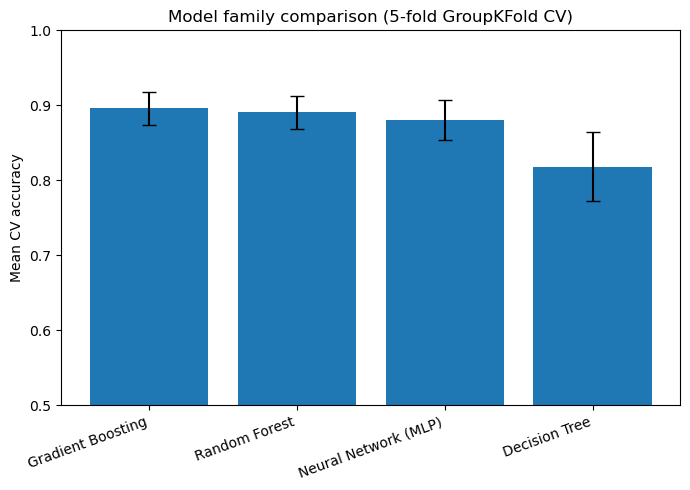

In [42]:
# Update the model family comparison to include the MLP
comparison = pd.concat([
    comparison,
    pd.DataFrame([{'model': 'Neural Network (MLP)', 'mean_acc': best_mlp['mean_acc'], 'std_acc': best_mlp['std_acc']}]),
], ignore_index=True).sort_values('mean_acc', ascending=False).reset_index(drop=True)
display(comparison)

plt.figure(figsize=(7, 5))
plt.bar(comparison['model'], comparison['mean_acc'], yerr=comparison['std_acc'], capsize=5)
plt.ylabel('Mean CV accuracy')
plt.title('Model family comparison (5-fold GroupKFold CV)')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Model 3: Softmax (Multinomial Logistic) Regression

sklearn's `LogisticRegression` fits a true multinomial softmax model directly (one linear score per class, normalized by softmax) rather than four separate one-vs-rest binary classifiers. Like the MLP, it's scale-sensitive, so we reuse `group_kfold_grid_search_scaled` to fit the `StandardScaler` inside each CV fold. The only hyperparameter to tune is `C` (inverse regularization strength): small `C` = stronger regularization = simpler decision boundary.

This is the linear baseline in the lineup -- comparing its CV accuracy to the tree ensembles and the MLP tells us how much of their edge comes from modeling nonlinear interactions vs. features that are already fairly linearly separable (e.g. `Q4` for Rio, `Q2` for NYC from the EDA).

In [43]:
from sklearn.linear_model import LogisticRegression

softmax_param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
}
softmax_cv_df = group_kfold_grid_search_scaled(
    LogisticRegression, softmax_param_grid, X_train, y_train, groups,
    fixed_params={'max_iter': 2000},
)
display(softmax_cv_df.drop(columns='fold_accs'))

,C,mean_acc,std_acc
0,0.010,0.882965,0.015506
1,0.100,0.881989,0.021595
2,1.000,0.881019,0.023136
3,10.000,0.878058,0.021905
4,100.000,0.877068,0.022733
5,0.001,0.875103,0.015851


In [44]:
# Refit the CV-selected softmax regression on the full training set (scaler fit on
# full train only), then check once against the held-out validation set.
best_softmax = softmax_cv_df.iloc[0]
print(f"Best params: C={best_softmax['C']}")
print(f"Per-fold accuracy scores: {[round(a, 3) for a in best_softmax['fold_accs']]}")
print(f"Mean: {best_softmax['mean_acc']:.3f}  Std: {best_softmax['std_acc']:.3f}")

softmax_scaler = StandardScaler()
X_train_scaled = softmax_scaler.fit_transform(X_train)
X_val_scaled = softmax_scaler.transform(X_val)

softmax_final = LogisticRegression(C=best_softmax['C'], max_iter=2000, random_state=42)
softmax_final.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, softmax_final.predict(X_train_scaled))
val_acc = accuracy_score(y_val, softmax_final.predict(X_val_scaled))
print(f"\nRefit on full train -- train acc: {train_acc:.3f}, val acc: {val_acc:.3f}")

val_pred = softmax_final.predict(X_val_scaled)
print("\nClassification report (val):")
print(classification_report(y_val, val_pred))



Best params: C=0.01
Per-fold accuracy scores: [0.892, 0.863, 0.907, 0.882, 0.871]
Mean: 0.883  Std: 0.016

Refit on full train -- train acc: 0.896, val acc: 0.950

Classification report (val):
                precision    recall  f1-score   support

         Dubai       0.95      0.95      0.95        55
 New York City       0.93      0.93      0.93        55
         Paris       0.94      0.93      0.94        55
Rio de Janeiro       0.98      1.00      0.99        53

      accuracy                           0.95       218
     macro avg       0.95      0.95      0.95       218
  weighted avg       0.95      0.95      0.95       218



,model,mean_acc,std_acc
0,Gradient Boosting,0.895744,0.021494
1,Random Forest,0.890861,0.021977
2,Softmax Regression,0.882965,0.015506
3,Neural Network (MLP),0.880072,0.027004
4,Decision Tree,0.818022,0.045806


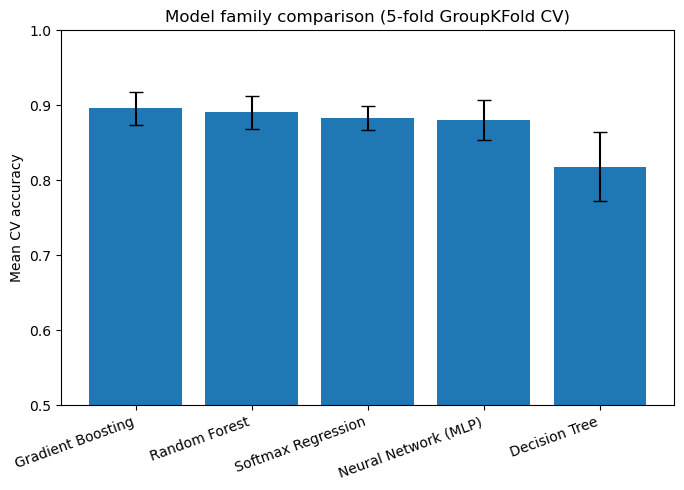

In [45]:
# Update the model family comparison to include softmax regression
comparison = pd.concat([
    comparison,
    pd.DataFrame([{'model': 'Softmax Regression', 'mean_acc': best_softmax['mean_acc'], 'std_acc': best_softmax['std_acc']}]),
], ignore_index=True).sort_values('mean_acc', ascending=False).reset_index(drop=True)
display(comparison)

plt.figure(figsize=(7, 5))
plt.bar(comparison['model'], comparison['mean_acc'], yerr=comparison['std_acc'], capsize=5)
plt.ylabel('Mean CV accuracy')
plt.title('Model family comparison (5-fold GroupKFold CV)')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()